In [1]:
import numpy as np
from numba import jit
import matplotlib.pyplot as plt
import simulation_cpu  as sim
import scipy.special as scp
import analyze_tool as an




dialctricl simllation varifction

- connection betwin S to power/pulse width / dt(time_cut) , as in void .
- vector pointing return and transmision: - match to theory
                                          - end material effcts(?) - hard to conclude


In [2]:
time_cut = 100
lamda = 8e-7 
time_cycal= lamda/sim.c
pulse_width = 4*time_cycal 
fea = np.pi/2
dt = time_cycal/time_cut
dz = 2*sim.c *dt


eps_r = 4
sigma =0
    

pulse_width = 3*time_cycal
ms0 = [0, 0, 1]
alpha =0.0001

close_system = False

len_matiral = 12*lamda


z1 = int(3*pulse_width/dt) +3
z2 = z1 + int(len_matiral/dz) 
lenz= z2 + time_cut//2





save_location = [4, z1, lenz- 6]
save_time = []

pik_enter_step = 4*int(pulse_width/dt)
void_steps = 2*z1
matiral_steps = int(2* eps_r**0.5* (z2 - z1))
exit_steps = 2*(lenz -z2)

simulation_time = 2*(pik_enter_step + void_steps + matiral_steps + exit_steps)
n = eps_r ** 0.5


t1_v = pik_enter_step + void_steps
t2_v = t1_v + void_steps
t3_v = t2_v + 2*matiral_steps
t2_5_v = (t2_v+ t3_v)//2



theoretical_reflectivity = (abs(( 1- n) /(1 + n))) ** 2

theoretical_transmision_field = 2/ (1 + eps_r**0.5)
theoretical_transmision_power = 1 - theoretical_reflectivity


Quick script to plot vector pointing in 3 important locations (Pulse enter, z1, end of simulation)

Transmition at z1 - 0.8888844376100685, expected : 0.8888888888888888
Return at z1 - -0.11244546527581557, expected : 0.11111111111111116


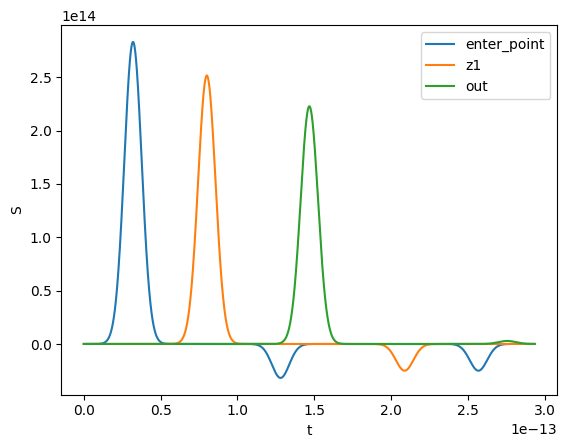

In [3]:
time_res, spece_res = sim.simulation(z1, z2, eps_r , sigma, alpha, ms0,
        4, fea , pulse_width,
        [4, z1, lenz- 6], save_time, False,
        dt, simulation_time, lamda )

E_real= sim.heta*spece_res[1]
H = spece_res[0]
S = np.cross(np.real(E_real),np.real(H))

S_in_enter_point = S[:,0,2]
S_in_z1 = S[:,1,2]
S_in_out = S[:,2,2]
time = np.arange(0, simulation_time) *dt

S_send_to_void = sum(S_in_enter_point[:t1_v])*dt
S_first_return_to_void = sum(S_in_enter_point[t1_v:t2_5_v])*dt
S_first_enter_to_matirial = sum(S_in_z1[:t2_v])*dt


transmition = S_first_enter_to_matirial/ S_send_to_void
Return = S_first_return_to_void/ S_send_to_void


plt.plot(time, S_in_enter_point)

plt.plot(time, S_in_z1)
plt.plot(time, S_in_out)
# plt.plot([secnd_retuen_time*dt, secnd_retuen_time*dt], [2.7e14, -0.1e14], "k")
plt.legend(["enter_point" , "z1", "out"])
plt.ylabel("S")
plt.xlabel("t")
# for i, ind in enumerate(save_location):
print(f"Transmition at z1 - {transmition}, expected : {theoretical_transmision_power}")
# print(f"Transmition at z2 - {transmition_z2}, expected : {theoretical_transmision_power_z2}")
print(f"Return at z1 - {Return}, expected : {1 - theoretical_transmision_power}")
# print(f"Return at z2 - {return_z2}, expected : {1 - theoretical_transmision_power_z2}")


check1
 - power in effact on S

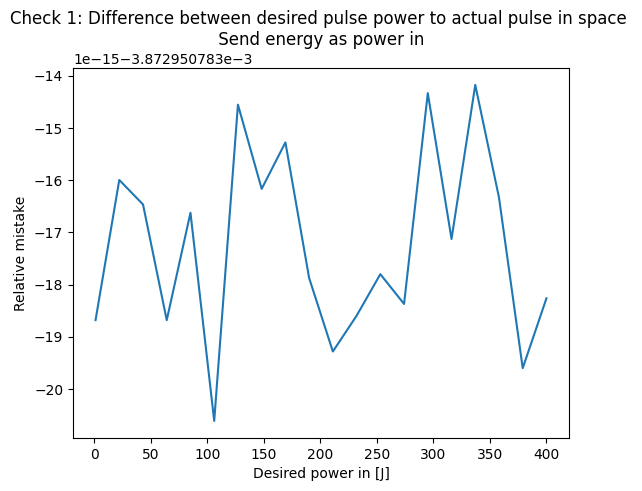

Text(0.5, 1.0, ' Transmition and return Factors \n Mean error of transmition form theory: -4.451278819439519e-06')

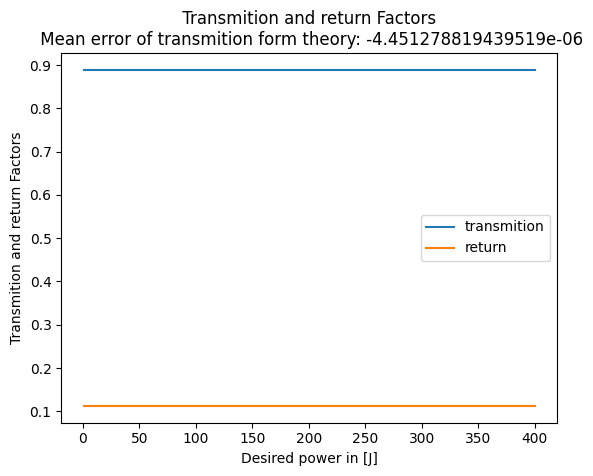

In [4]:
energy_in = np.linspace(1, 400, 20)
S_comp = np.zeros(np.size(energy_in))
transmition_vec = np.zeros(np.size(energy_in))
return_vec = np.zeros(np.size(energy_in))

for i, E in enumerate(energy_in):
    
        
    time_res, spece_res = sim.simulation(z1, z2, eps_r , sigma, alpha, ms0,
            E, fea , pulse_width,
            save_location, save_time, False,
            dt, simulation_time, lamda )

    E_real= sim.heta*spece_res[1]
    H = spece_res[0]
    S = np.cross(np.real(E_real),np.real(H))

    
    S_in_enter_point = S[:,0,2]
    S_in_z1 = S[:,1,2]
    S_in_out = S[:,2,2]

    S_send_to_void = sum(S_in_enter_point[:t1_v])*dt
    S_first_return_to_void = sum(S_in_enter_point[t1_v:t2_5_v])*dt
    S_first_enter_to_matirial = sum(S_in_z1[:t2_v])*dt


    transmition_vec[i] = S_first_enter_to_matirial/ S_send_to_void
    return_vec[i] = - S_first_return_to_void/ S_send_to_void
    S_comp[i] = S_send_to_void
    

check1_s=( (energy_in - S_comp)/energy_in)
plt.plot(energy_in, check1_s)
plt.xlabel("Desired power in [J]")
plt.title("Check 1: Difference between desired pulse power to actual pulse in space \n Send energy as power in ")
plt.ylabel("Relative mistake")
plt.show()

plt.plot(energy_in, transmition_vec)
plt.plot(energy_in, return_vec)
plt.legend(["transmition" ,  "return"])
plt.xlabel("Desired power in [J]")
plt.ylabel("Transmition and return Factors")
plt.title(f" Transmition and return Factors \n Mean error of transmition form theory: {np.mean(transmition_vec- theoretical_transmision_power)}")

check 2 
Does polarization change the energy in, and Transmision and Return factors.

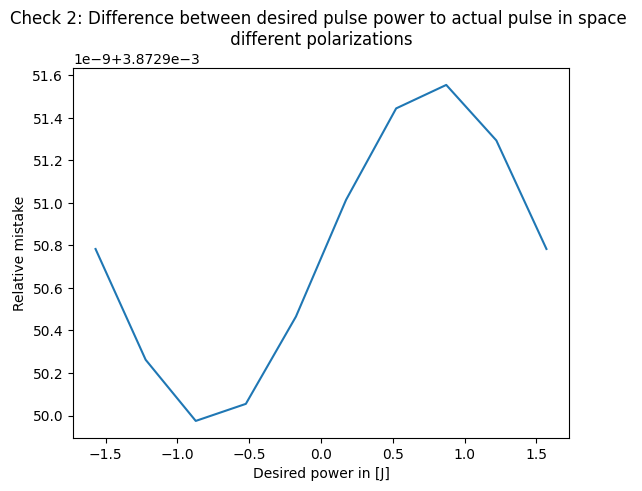

Text(0.5, 1.0, 'Transmition and return Factors \n mean error of transmition form theory: -4.451383298254008e-06')

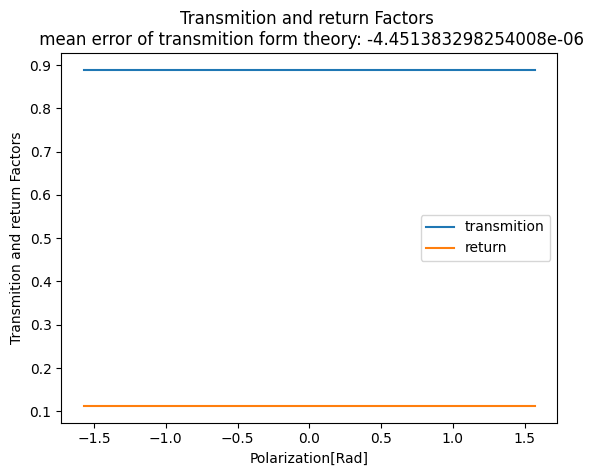

In [ ]:
polarization_vec = np.linspace(-np.pi/2, np.pi/2, 10)
S_comp = np.zeros(np.size(polarization_vec))
transmition_vec = np.zeros(np.size(polarization_vec))
return_vec = np.zeros(np.size(polarization_vec))
Powerin = 4


for i, p in enumerate(polarization_vec):
    
        
    time_res, spece_res = sim.simulation(z1, z2, eps_r , sigma, alpha, ms0,
            Powerin, p , pulse_width,
            save_location, save_time, False,
            dt, simulation_time, lamda )

    E_real= sim.heta*spece_res[1]
    H = spece_res[0]
    S = np.cross(np.real(E_real),np.real(H))
    S_in_enter_point = S[:,0,2]
    S_in_z1 = S[:,1,2]
    S_in_out = S[:,2,2]

    S_send_to_void = sum(S_in_enter_point[:t1_v])*dt
    S_first_return_to_void = sum(S_in_enter_point[t1_v:t2_5_v])*dt
    S_first_enter_to_matirial = sum(S_in_z1[:t2_v])*dt


    transmition_vec[i] = S_first_enter_to_matirial/ S_send_to_void
    return_vec[i] = - S_first_return_to_void/ S_send_to_void
    S_comp[i] = S_send_to_void
    

check2_s = abs( (Powerin - S_comp)/Powerin)
plt.plot(polarization_vec, check2_s)
plt.xlabel("Desired power in [J]")
plt.title("Check 2: Difference between desired pulse power to actual pulse in space \n Different polarizations ")
plt.ylabel("Relative mistake")
plt.show()

plt.plot(polarization_vec, transmition_vec)
plt.plot(polarization_vec, return_vec)
plt.legend(["transmition" ,  "return"])
plt.xlabel("Polarization[Rad]")
plt.ylabel("Transmition and return Factors")
plt.title(f"Transmition and return Factors \n Mean error of transmition form theory: {np.mean(transmition_vec- theoretical_transmision_power)}")

check 3:
Pulse width effect on the energy in and Transmision and Return factors.

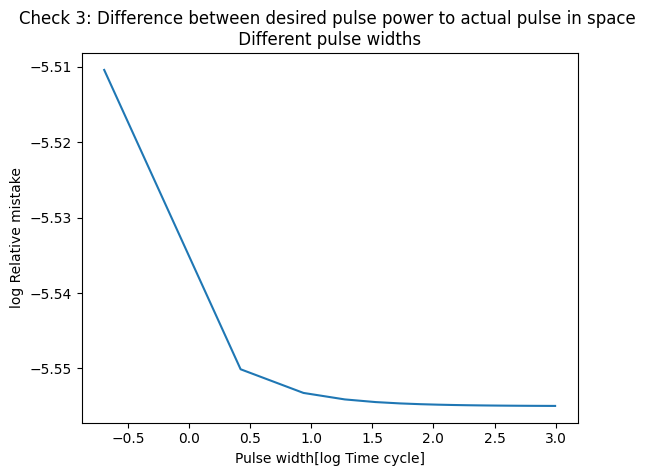

Text(0.5, 1.0, 'Transmition and return Factors \n Mean error of transmition form theory: -4.498471758695999e-06')

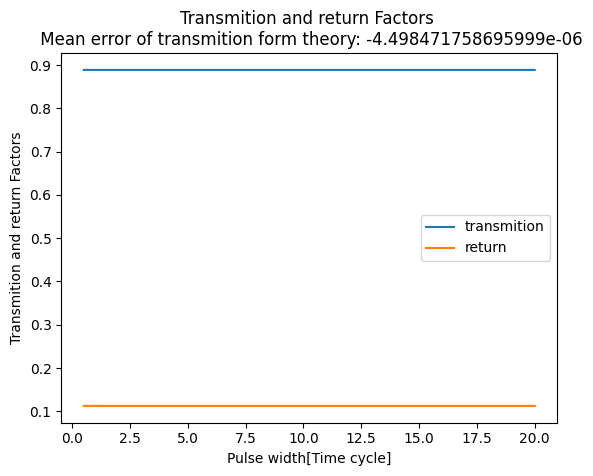

In [ ]:
pulse_width_vec = np.linspace(0.5, 20 , 20) * time_cycal
S_comp = np.zeros(np.size(pulse_width_vec))
transmition_vec = np.zeros(np.size(pulse_width_vec))
return_vec = np.zeros(np.size(pulse_width_vec))


for i, width in enumerate(pulse_width_vec):


    pik_enter_step_i = 4*(width//dt)
    len_matiral_i = int(2*width//dt)

    z1_i = int(2*width/dt) +3
    z2_i = z1_i + int(len_matiral_i) 
    lenz_i= z2_i + time_cut//2

    pik_enter_step_i = 4*(width//dt)
    void_steps_i = 2*z1_i
    matiral_steps_i= int(2* eps_r**0.5* (z2_i - z1_i))
    exit_steps_i = 2*(lenz_i -z2_i)

    time_run_i = int(2*(pik_enter_step_i + void_steps_i + matiral_steps_i + exit_steps_i))


    t1_ch3 = int(pik_enter_step_i + void_steps_i)
    t2_ch3 = t1_ch3 + void_steps_i
    t3_ch3 = t2_ch3 + 2*matiral_steps_i
    t2_5_ch3 = (t2_ch3+ t3_ch3)//2
    save_location_i = [4, z1_i, lenz_i- 6]



    time_res, spece_res = sim.simulation(z1_i, z2_i, eps_r , sigma, alpha, ms0,
            Powerin, fea , width,
            save_location_i, [], False,
            dt, time_run_i, lamda )



    E_real= sim.heta*spece_res[1]
    H = spece_res[0]
    S = np.cross(np.real(E_real),np.real(H))
    S_in_enter_point = S[:,0,2]
    S_in_z1 = S[:,1,2]
    S_in_out = S[:,2,2]

    S_send_to_void = sum(S_in_enter_point[:t1_ch3])*dt
    S_first_return_to_void = sum(S_in_enter_point[t1_ch3:t2_5_ch3])*dt
    S_first_enter_to_matirial = sum(S_in_z1[:t2_ch3])*dt


    transmition_vec[i] = S_first_enter_to_matirial/ S_send_to_void
    return_vec[i] = - S_first_return_to_void/ S_send_to_void
    S_comp[i] = S_send_to_void
 


check3_s = abs( (Powerin - S_comp)/Powerin)
plt.plot(np.log(pulse_width_vec/time_cycal), np.log(check3_s))
plt.xlabel("Pulse width[log Time cycle]")
plt.title("Check 3: Difference between desired pulse power to actual pulse in space \n Different pulse widths ")
plt.ylabel("log Relative mistake")
plt.show()

plt.plot(pulse_width_vec/time_cycal, transmition_vec)
plt.plot(pulse_width_vec/time_cycal, return_vec)
plt.legend(["transmition" ,  "return"])
plt.xlabel("Pulse width[Time cycle]")
plt.ylabel("Transmition and return Factors")
plt.title(f"Transmition and return Factors \n Mean error of transmition form theory: {np.mean(transmition_vec- theoretical_transmision_power)}")

chack 4
time cut efact on the power in and transmition and return factors

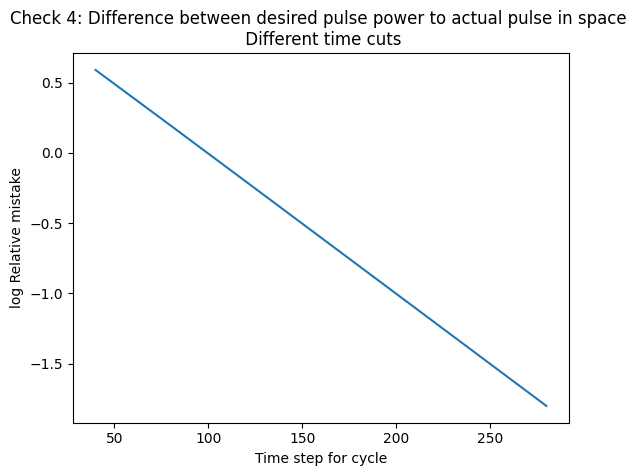

Text(0.5, 1.0, 'Transmition and return Factors \n Mean error of transmition form theory: -2.949565762244699e-05')

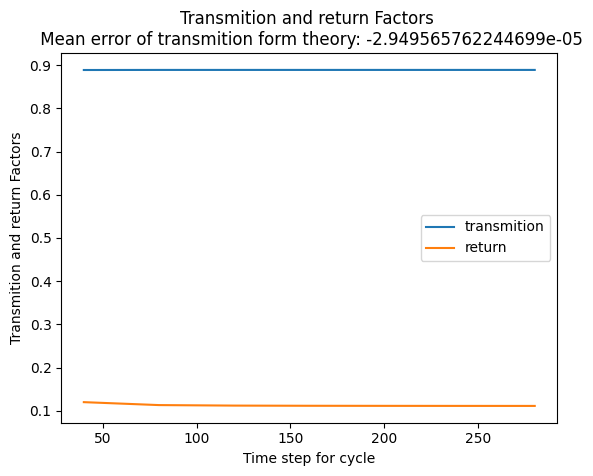

In [ ]:
times_cut = np.arange(40,300,40)
S_comp= np.zeros(np.size(times_cut))
pulse_width = 4*time_cycal

transmition_vec = np.zeros(np.size(times_cut))
return_vec = np.zeros(np.size(times_cut))


for i, tc in enumerate(times_cut):
    dt_i = time_cycal/tc

    len_matiral_i = int(2*pulse_width//dt_i)

    z1_i = int(2*pulse_width/dt_i) +3
    z2_i = z1_i + int(len_matiral_i) 
    lenz_i= z2_i + tc//2


    pik_enter_step_i = 4*(pulse_width//dt_i)
    void_steps_i = 2*z1_i
    matiral_steps_i= int(2* eps_r**0.5* (z2_i - z1_i))
    exit_steps_i = 2*(lenz_i -z2_i)

    time_run_i = int(2*(pik_enter_step_i + void_steps_i + matiral_steps_i + exit_steps_i))


    t1_ch4 = int(pik_enter_step_i + void_steps_i)
    t2_ch4 = t1_ch4 + void_steps_i
    t3_ch4 = t2_ch4 + 2*matiral_steps_i
    t2_5_ch4 = (t2_ch4+ t3_ch4)//2
    save_location_i = [4, z1_i, lenz_i- 6]



    time_res, spece_res = sim.simulation(z1_i, z2_i, eps_r , sigma, alpha, ms0,
            Powerin, fea , pulse_width,
            save_location_i, [], False,
            dt_i, time_run_i, lamda )



    E_real= sim.heta*spece_res[1]
    H = spece_res[0]
    S = np.cross(np.real(E_real),np.real(H))
    S_in_enter_point = S[:,0,2]
    S_in_z1 = S[:,1,2]
    S_in_out = S[:,2,2]

    S_send_to_void = sum(S_in_enter_point[:t1_ch4])*dt
    S_first_return_to_void = sum(S_in_enter_point[t1_ch4:t2_5_ch4])*dt
    S_first_enter_to_matirial = sum(S_in_z1[:t2_ch4])*dt


    transmition_vec[i] = S_first_enter_to_matirial/ S_send_to_void
    return_vec[i] = - S_first_return_to_void/ S_send_to_void
    S_comp[i] = S_send_to_void


check4_s = ( (Powerin - S_comp)/Powerin)
plt.plot(times_cut, check4_s)
plt.xlabel("Time step for cycle")
plt.title("Check 4: Difference between desired pulse power to actual pulse in space \n Different time cuts")
plt.ylabel("log Relative mistake")
plt.show()

plt.plot(times_cut, transmition_vec)
plt.plot(times_cut, return_vec)
plt.legend(["transmition" ,  "return"])
plt.xlabel("Time step for cycle")
plt.ylabel("Transmition and return Factors")
plt.title(f"Transmition and return Factors \n Mean error of transmition form theory: {np.mean(transmition_vec- theoretical_transmision_power)}")

chack 5- 
eps_r change

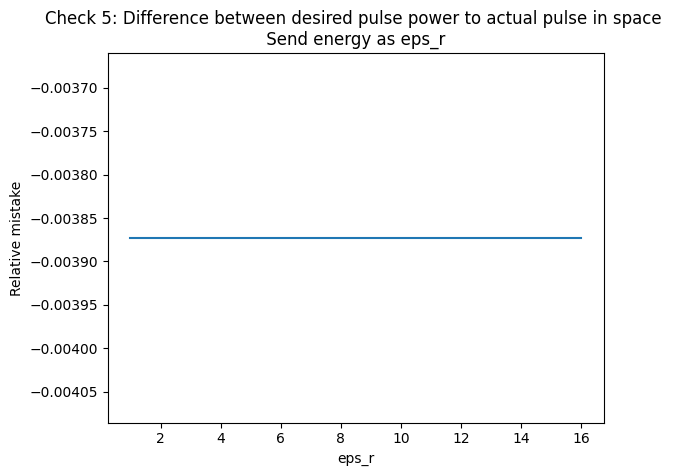

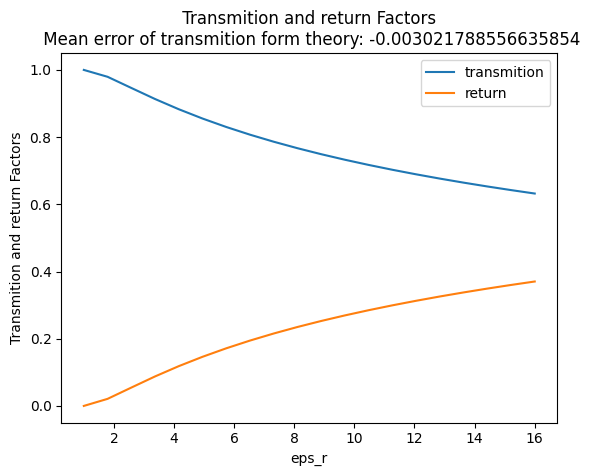

C:\Users\owner\AppData\Local\Temp\ipykernel_20696\1329888320.py:53: RuntimeWarning: divide by zero encountered in divide
  check6_epr = (return_vec - theoretical_reflectivity_vec)/theoretical_reflectivity_vec


Text(0.5, 1.0, 'return Factor error')

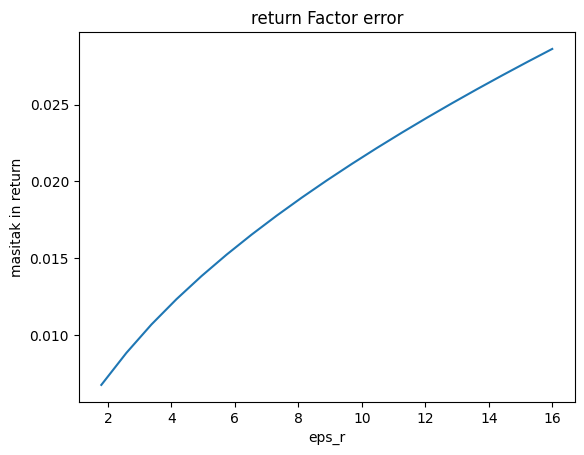

In [7]:
Powerin = 3
eps_r_vec = np.linspace(1, 16, 20)
S_comp = np.zeros(np.size(eps_r_vec))
transmition_vec = np.zeros(np.size(eps_r_vec))
return_vec = np.zeros(np.size(eps_r_vec))

n_vec = eps_r_vec**0.5
theoretical_reflectivity_vec = (abs(( 1- n_vec) /(1 + n_vec))) ** 2



for i, er in enumerate(eps_r_vec):
    
        
    time_res, spece_res = sim.simulation(z1, z2, er , sigma, alpha, ms0,
            Powerin, fea , pulse_width,
            save_location, save_time, False,
            dt, simulation_time, lamda )

    E_real= sim.heta*spece_res[1]
    H = spece_res[0]
    S = np.cross(np.real(E_real),np.real(H))
    S_in_enter_point = S[:,0,2]
    S_in_z1 = S[:,1,2]
    S_in_out = S[:,2,2]

    S_send_to_void = sum(S_in_enter_point[:t1_v])*dt
    S_first_return_to_void = sum(S_in_enter_point[t1_v:t2_5_v])*dt
    S_first_enter_to_matirial = sum(S_in_z1[:t2_v])*dt


    transmition_vec[i] = S_first_enter_to_matirial/ S_send_to_void
    return_vec[i] = - S_first_return_to_void/ S_send_to_void
    S_comp[i] = S_send_to_void
    

check5_s=( (Powerin - S_comp)/Powerin)
plt.plot(eps_r_vec, check5_s)
plt.xlabel("eps_r")
plt.title("Check 5: Difference between desired pulse power to actual pulse in space \n Send energy as eps_r ")
plt.ylabel("Relative mistake")
plt.show()


plt.plot(eps_r_vec, transmition_vec)
plt.plot(eps_r_vec, return_vec)
plt.legend(["transmition" ,  "return"])
plt.xlabel("eps_r")
plt.ylabel("Transmition and return Factors")
plt.title(f" Transmition and return Factors \n Mean error of transmition form theory: {np.mean(transmition_vec- 1+ theoretical_reflectivity_vec)}")
plt.show()

check6_epr = (return_vec - theoretical_reflectivity_vec)/theoretical_reflectivity_vec 
plt.plot(eps_r_vec, check6_epr)
plt.xlabel("eps_r")
plt.ylabel("masitak in return")
plt.title("return Factor error")